In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [7]:
df=pd.read_csv("House Price Prediction Dataset.csv")
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


Task 1

In [8]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

The dataset does not contain missing values. All columns have 2000 non-null entries. However, the
dataset contains categorical features (Location, Condition, Garage) that may require encoding for
machine learning models. Additionally, the Id column is an identifier and does not provide predictive
information.

*Task 2 — Missing Value Strategy*

In [13]:
df_missing= df.copy()
df_missing.loc[0:5, 'Area']=np.nan
df_missing.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,NaN,5,4,3,1970,Downtown,Excellent,No,149919
1,2,NaN,5,4,3,1958,Downtown,Excellent,No,424998
2,3,NaN,2,2,3,1938,Downtown,Good,No,266746
3,4,NaN,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,NaN,1,4,2,1975,Downtown,Fair,Yes,636056


In [14]:
df_missing['Area']=df_missing['Area'].fillna(df_missing['Area'].mean())
df_missing.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,2785.034604,5,4,3,1970,Downtown,Excellent,No,149919
1,2,2785.034604,5,4,3,1958,Downtown,Excellent,No,424998
2,3,2785.034604,2,2,3,1938,Downtown,Good,No,266746
3,4,2785.034604,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,2785.034604,1,4,2,1975,Downtown,Fair,Yes,636056


Since the dataset does not contain missing values, artificial missing values were
introduced for demonstration purposes. The missing values were handled using mean
imputation because it preserves the dataset size and is appropriate for numerical
features.

*Task 3 — Detect and Handle Outliers using IQR*

In [21]:
#Before removing outliers
print(df['Price'].describe())

count      2000.000000
mean     537676.855000
std      276428.845719
min       50005.000000
25%      300098.000000
50%      539254.000000
75%      780086.000000
max      999656.000000
Name: Price, dtype: float64


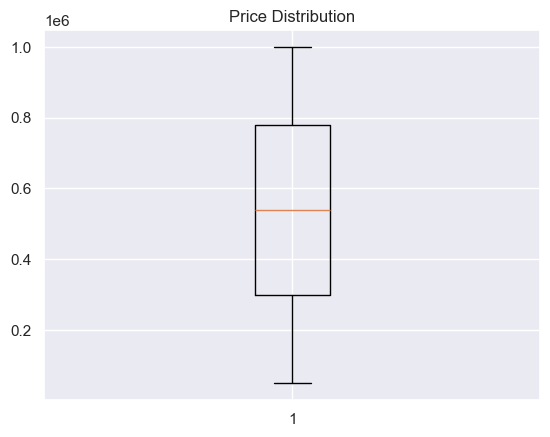

In [31]:
plt.boxplot(df['Price'])
plt.title("Price Distribution")
plt.show()

In [32]:
Q1= df['Price'].quantile(0.25)
Q3= df['Price'].quantile(0.75)
IQR= Q3-Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['Price'] < lower) | (df['Price'] > upper)]


In [33]:
df['Price'] = df['Price'].clip(lower, upper)
#After removing outliers
print(df['Price'].describe())
print("Number of outliers:", len(outliers))

count      2000.000000
mean     537676.855000
std      276428.845719
min       50005.000000
25%      300098.000000
50%      539254.000000
75%      780086.000000
max      999656.000000
Name: Price, dtype: float64
Number of outliers: 0


After applying the IQR method on the Price column, no outliers were detected
because all values fall within the acceptable range [Q1-1.5IQR, Q3+1.5IQR].
Therefore, no changes were applied to the dataset

*Task 4 — Normalization*

In [34]:
print(df[['Area','Price']].head())

   Area   Price
0  1360  149919
1  4272  424998
2  3592  266746
3   966  244020
4  4926  636056


In [36]:
from sklearn.preprocessing import MinMaxScaler
scaler =MinMaxScaler()
df_minmax =df.copy()
df_minmax[['Area','Price']] = scaler.fit_transform(df_minmax[['Area','Price']])

#After Min-Max Normalization
print(df_minmax[['Area','Price']].head())

       Area     Price
0  0.190974  0.105211
1  0.838373  0.394875
2  0.687194  0.228232
3  0.103379  0.204301
4  0.983771  0.617123


Min-Max normalization scales values between 0 and 1 while preserving the relative
relationships between observations.

In [39]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()

df_zscore= df.copy()
df_zscore[['Area','Price']]= scaler.fit_transform(df_zscore[['Area','Price']])

#After Z-score
print(df_zscore[['Area','Price']].head())

       Area     Price
0 -1.101471 -1.403091
1  1.147485 -0.407725
2  0.622317 -0.980356
3 -1.405759 -1.062589
4  1.652574  0.355982


Z-score normalization standardizes the features so that they have a mean of 0 and a standard deviation of 1.

*Task 5 — PCA*

In [40]:
print(df[['Area','Bedrooms','Bathrooms','Floors','Price']].corr())

               Area  Bedrooms  Bathrooms    Floors     Price
Area       1.000000  0.047523   0.021881  0.017749  0.001542
Bedrooms   0.047523  1.000000  -0.011990  0.010435 -0.003471
Bathrooms  0.021881 -0.011990   1.000000  0.029089 -0.015737
Floors     0.017749  0.010435   0.029089  1.000000  0.055890
Price      0.001542 -0.003471  -0.015737  0.055890  1.000000


In [41]:
from sklearn.decomposition import PCA

X = df_zscore[['Area','Bedrooms','Bathrooms','Floors']]

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.41395123 0.25099532]


The correlation matrix shows very weak correlations between the numerical features
(values close to 0). Since PCA is most useful when features are highly correlated,
applying PCA would not significantly reduce redundancy in this dataset. 